In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [19]:
emails_df = pd.read_csv('../data/03_manual_labelled_emails.csv')
emails_df.head()

,Date,From,To,Subject,X_From,X_To,Message,Entire-Message,DISC_rule,DISC_manual,DISC_final
0,"Fri, 4 May 2001 13:51:00 -0700 (PDT)",phillip.allen@enron.com,john.lavorato@enron.com,Re:,Phillip K Allen,John J Lavorato <John J Lavorato/ENRON@enronXg...,Traveling to have a business meeting takes the...,Re: Traveling to have a business meeting takes...,NaN,"['I', 'C']",NaN
1,"Mon, 16 Oct 2000 06:42:00 -0700 (PDT)",phillip.allen@enron.com,buck.buckner@honeywell.com,Re: FW: fixed forward or other Collar floor ga...,Phillip K Allen,"""Buckner, Buck"" <buck.buckner@honeywell.com> @...","Mr. Buckner,\nFor delivered gas behind San Die...",Re: FW: fixed forward or other Collar floor ga...,NaN,['S'],NaN
2,"Fri, 13 Oct 2000 06:45:00 -0700 (PDT)",phillip.allen@enron.com,stagecoachmama@hotmail.com,No Subject,Phillip K Allen,stagecoachmama@hotmail.com,"Lucy,\nHere are the rentrolls:\nOpen them and ...","No Subject Lucy,\nHere are the rentrolls:\nOpe...",NaN,['S'],NaN
3,"Tue, 3 Oct 2000 09:13:00 -0700 (PDT)",phillip.allen@enron.com,bs_stone@yahoo.com,No Subject,Phillip K Allen,bs_stone@yahoo.com,"Brenda,\nPlease use the second check as the Oc...","No Subject Brenda,\nPlease use the second chec...",NaN,['S'],NaN
4,"Mon, 2 Oct 2000 02:19:00 -0700 (PDT)",phillip.allen@enron.com,bs_stone@yahoo.com,Re: OrigiNl Sept check/closing,Phillip K Allen,"""BS Stone"" <bs_stone@yahoo.com> @ ENRON","Brenda,\nPlease use the second check as my Oct...","Re: OrigiNl Sept check/closing Brenda,\nPlease...",NaN,['S'],NaN


In [20]:
emails_df.columns

Index(['Date', 'From', 'To', 'Subject', 'X_From', 'X_To', 'Message',
       'Entire-Message', 'DISC_rule', 'DISC_manual', 'DISC_final'],
      dtype='object')

In [21]:
emails_df.info()
emails_df.describe(include='all').T
# emails_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64442 entries, 0 to 64441
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            64442 non-null  object 
 1   From            64442 non-null  object 
 2   To              64442 non-null  object 
 3   Subject         64442 non-null  object 
 4   X_From          64442 non-null  object 
 5   X_To            64442 non-null  object 
 6   Message         64442 non-null  object 
 7   Entire-Message  64442 non-null  object 
 8   DISC_rule       0 non-null      float64
 9   DISC_manual     64442 non-null  object 
 10  DISC_final      0 non-null      float64
dtypes: float64(2), object(9)
memory usage: 5.4+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,64442,61174,"Mon, 31 Dec 1979 16:00:00 -0800 (PST)",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
From,64442,4926,kay.mann@enron.com,1615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
To,64442,25008,louise.kitchen@enron.com,794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Subject,64442,48244,No Subject,2206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X_From,64442,7219,Kay Mann,1545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X_To,64442,28929,Tana Jones,691,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Message,64442,64356,Ken Lay returned to the CEO's office,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Entire-Message,64442,64357,he is already shopping for office space.,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISC_rule,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DISC_manual,64442,10,[],64334,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# emails_df = emails_df.loc[:, ~emails_df.columns.str.startswith('Unnamed')]
emails_df_disc_label = emails_df.drop(columns=['X_From', 'X_To', 'Date', 'From', 'To', 'Subject', 'Message'])
emails_df_disc_label.head()

,Entire-Message,DISC_rule,DISC_manual,DISC_final
0,Re: Traveling to have a business meeting takes...,NaN,"['I', 'C']",NaN
1,Re: FW: fixed forward or other Collar floor ga...,NaN,['S'],NaN
2,"No Subject Lucy,\nHere are the rentrolls:\nOpe...",NaN,['S'],NaN
3,"No Subject Brenda,\nPlease use the second chec...",NaN,['S'],NaN
4,"Re: OrigiNl Sept check/closing Brenda,\nPlease...",NaN,['S'],NaN


In [23]:
emails_df_disc_label.to_csv('../data/03_cleaned_email_msg.csv', index=False)

## Use Rule-Based Keyword Matching to label sample emails

In [54]:
emails_df_rule_based_samples = emails_df_disc_label.sample(3000, random_state=32).copy()
rule_based_ids = emails_df_rule_based_samples.index.tolist()
print(rule_based_ids)

[22402, 21391, 8258, 27522, 44698, 28785, 35942, 47543, 6046, 44871, 1859, 56643, 10520, 34745, 51136, 14907, 38780, 16517, 41111, 12858, 5656, 33682, 57467, 42476, 26374, 24486, 1082, 48279, 11756, 3671, 8297, 45293, 61513, 63957, 53607, 40771, 53219, 37136, 29131, 23048, 39512, 26436, 20846, 61363, 34424, 42240, 41081, 24895, 37825, 39945, 26, 56268, 41968, 15925, 22747, 29144, 23178, 6903, 5476, 11589, 56200, 5698, 18845, 42393, 8888, 56336, 11602, 1006, 39426, 11681, 44091, 49126, 57696, 43466, 9219, 5162, 59120, 10669, 8336, 48656, 30576, 49753, 37954, 55830, 25669, 27309, 34021, 14233, 58550, 26258, 58422, 1500, 64315, 48122, 46337, 22860, 33628, 53618, 11676, 13940, 63399, 14048, 9537, 42481, 19296, 22541, 39522, 10023, 55512, 53658, 48881, 24094, 43561, 14227, 13280, 59494, 47037, 12805, 27416, 16971, 49061, 41461, 37303, 36273, 29953, 14467, 44297, 31606, 42521, 28148, 5670, 29376, 28363, 13282, 33581, 6011, 53186, 9035, 25879, 24516, 46253, 4346, 49783, 22811, 17787, 31233, 4

In [55]:
# lowercasing and remove punctuation
PUNC_PATTERN = re.compile(r'[^\w\s]')

def preprocess_text_for_rule_based(text):
    if not isinstance(text, str):
        return ''


    text = PUNC_PATTERN.sub('', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip().lower()
    return text

emails_df_rule_based_samples['Entire-Message'] = emails_df_rule_based_samples['Entire-Message'].apply(preprocess_text_for_rule_based)
emails_df_rule_based_samples.head()

,Entire-Message,DISC_rule,DISC_manual,DISC_final
22402,eott sub unit options plan stan this my unders...,NaN,[],NaN
21391,forest and noble gas marie since jay is out th...,NaN,[],NaN
8258,news quick read calif electric lottery an edit...,NaN,[],NaN
27522,29th floor tana the suite of offices on 29 wil...,NaN,[],NaN
44698,project teams detailed below are the project t...,NaN,[],NaN


In [56]:
DISC_KEYWORDS = {
    'D' : ["deadline", "urgent", "now", "action", "priority", "resolve", "results",
        "decision", "goal", "challenge", "do it", "fast", "push", "lead", "firm", "pressure", "action required",
        "quickly", "at all costs", "make it happen", "efficiently", "asap"
        "take the lead", "take action", "do it now", "get this done", "make sure",
        "ensure", "enforce", "absolutely", "direct", "right now", "immediately",
        "speed", "I want", "I said", "must",  "put questions to rest", "your fault",
        "your mistake", "your apologies", "your bad", "your error", "your oversight",
        "your slip", "your blunder", "your carelessness", "your inattention",
        "your neglect", "your omission", "your oversight", "I guarantee",
        "enough is enough", " you need to", "fuck you"],
    'I' : ["excited", "great job", "lets", "share", "appreciate",
        "celebrate", "fun", "engage", "collaborate", "believe",
          "nice to hear", "amazing", "awesome", "fantastic", "get a hold of me",
          "discuss", "chat", "jokes", "laugh", "smile", "happy", "good news", "favorite",
          "favourite", "celebrate", "congratulations", "kudos", "celebration", "party",
          "playing", "exciting", "thrilling", "enjoy", "game"],
    'S' : ["kindly", "let me know", "available", "cooperate", "help", "understand",
        "follow up", "consistent", "appreciate your help", "thanks again",
        "dont worry", "help in any way I can", "let me know", "comfortable",
        "sorry for not responding", "thank you so much", "my fault", "my mistake",
        "my apologies", "my bad", "my error", "my oversight", "my slip", "my blunder",
        "my carelessness", "my inattention", "my neglect", "my omission", "my oversight",
        "sorry", "apologize for", "agree"],
    'C' : ["details", "data", "report", "analyze", "summary", "document", "proof",
        "schedule", "spreadsheet", "accuracy", "format", "process", "standards", "analysis",
        "compliance", "audit", "method", "evidence", "confirm", "structured", "sources",
        "review", "check", "validate", "verify", "validate", "as per", "according to",
        "in accordance with", "consistent with", "comply with", "follow", "procedure",
        "guideline", "manual", "policy", "regulation", "rule", "standard", "statute",
        "requirement", "specification", "protocol", "principle", "reconcile", "cross-check",
        "cross-reference", "corroborate", "substantiate", "authenticate", "confirm", "justify",
        "hindsight", "forethought", "foresight", "insight", "formula", "unjustified",
        "unsubstantiated", "unverified", "unvalidated", "unconfirmed", "unjust", "unreasonable",
        "looking into", "investigate", "examine", "probe", "scrutinize", "inspect", "identified",
        "final execution", "implementation", "calculation", "agreement", "calibrate"]
}

In [57]:
# # for later use
# def match_disc_label_list(msg):
#     disc_labels = set()
#     for label, keywords in DISC_KEYWORDS.items():
#         for word in keywords:
#             if word in msg:
#                 disc_labels.add(label)

#     return disc_labels

# for bar chart

DISC_order = ['D', 'I', 'S', 'C']

def match_disc_label(msg, max_freq=2):
    labels_freq = {'D': 0, 'I': 0, 'S': 0, 'C': 0}
    for label, keywords in DISC_KEYWORDS.items():
        for word in keywords:
            if word in msg:
                labels_freq[label] += 1
    # print(labels_freq)

    filter_labels = {label: freq for label, freq in labels_freq.items() if freq > 0}
    if not filter_labels:
        return []

    # sorted_labels_freq = sorted(filter_labels.items(), key=lambda x: (-x[1], x[0]))
    sorted_labels_freq = sorted(filter_labels.items(), key=lambda x: x[0] in DISC_order)
    return [label for label, freq in sorted_labels_freq[:max_freq]]

# for use later
# emails_df_rule_based_samples['DISC_rule'] = emails_df_rule_based_samples['Entire-Message'].apply(match_disc_label_list)
# print("list: ", )
# for bar chart
emails_df_rule_based_samples['DISC_rule'] = emails_df_rule_based_samples['Entire-Message'].apply(match_disc_label)

print(emails_df_rule_based_samples.head(5))

label_count_tuple = emails_df_rule_based_samples['DISC_rule'].value_counts()
print(label_count_tuple)


                                          Entire-Message DISC_rule  \
22402  eott sub unit options plan stan this my unders...    [I, S]   
21391  forest and noble gas marie since jay is out th...        []   
8258   news quick read calif electric lottery an edit...       [C]   
27522  29th floor tana the suite of offices on 29 wil...    [I, C]   
44698  project teams detailed below are the project t...    [D, C]   

      DISC_manual  DISC_final  
22402          []         NaN  
21391          []         NaN  
8258           []         NaN  
27522          []         NaN  
44698          []         NaN  
DISC_rule
[D, I]    737
[D, S]    536
[]        389
[C]       336
[D, C]    279
[D]       194
[S, C]    146
[I]       132
[I, S]    104
[I, C]     87
[S]        60
Name: count, dtype: int64


DISC_rule
(D, I)    737
(D, S)    536
()        389
(C,)      336
(D, C)    279
(D,)      194
(S, C)    146
(I,)      132
(I, S)    104
(I, C)     87
(S,)       60
Name: count, dtype: int64


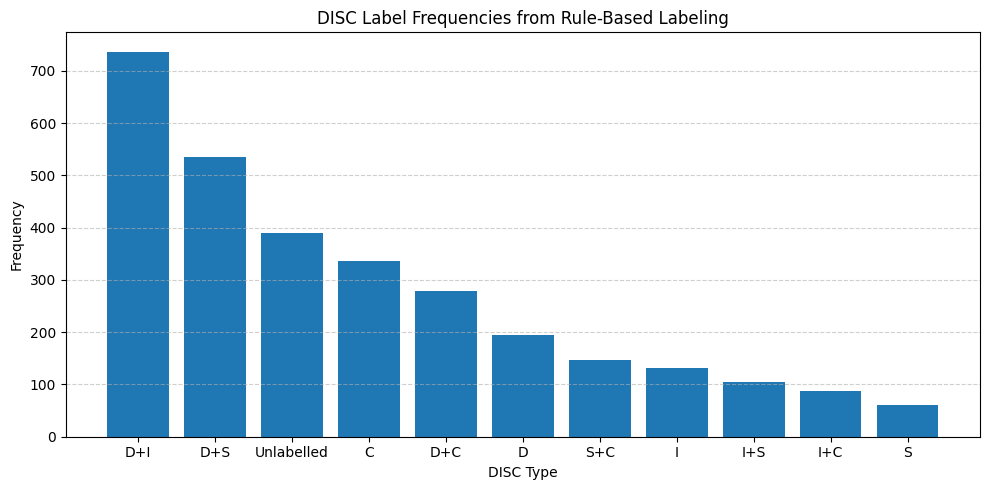

<Figure size 640x480 with 0 Axes>

In [ ]:

label_count_tuple = emails_df_rule_based_samples['DISC_rule'].apply(lambda x: tuple(x) if isinstance(x, list) else ()).value_counts()

print(label_count_tuple)

x_labels = label_count_tuple.index.map(lambda x: 'Unlabelled' if isinstance(x, tuple) and len(x) == 0
                                 else '+'.join(x) if isinstance(x, tuple)
                                else str(x))


plt.figure(figsize=(10, 5))
plt.bar(x_labels, label_count_tuple.values)
plt.title("DISC Label Frequencies from Rule-Based Labeling")
plt.xlabel("DISC Type")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.savefig('../figures/04_rule_based_sample_label_freq.png')

## Combine the rule-based labelled samples back into the main emails df

In [ ]:

emails_df.loc[rule_based_ids, 'DISC_rule'] = emails_df_rule_based_samples['DISC_rule']
emails_df.sample(10, random_state=32)

,Date,From,To,Subject,X_From,X_To,Message,Entire-Message,DISC_rule,DISC_manual,DISC_final
22402,"Wed, 15 Mar 2000 09:56:00 -0800 (PST)",michael.burke@enron.com,stanley.horton@enron.com,EOTT Sub Unit Options plan,Michael Burke,Stanley Horton,"Stan,\nThis my understanding of the proposal\n...","EOTT Sub Unit Options plan Stan,\nThis my unde...","[I, S]",[],NaN
21391,"Mon, 19 Nov 2001 13:33:56 -0800 (PST)",max.sonnonstine@enron.com,marie.heard@enron.com,Forest and Noble Gas,"Sonnonstine, Max </O=ENRON/OU=NA/CN=RECIPIENTS...","Heard, Marie </O=ENRON/OU=NA/CN=RECIPIENTS/CN=...","Marie,\nSince Jay is out this week, I'll be ""w...","Forest and Noble Gas Marie,\nSince Jay is out ...",[],[],NaN
8258,"Tue, 8 May 2001 03:52:00 -0700 (PDT)",jennifer.rudolph@enron.com,ca.team@enron.com,NEWS: quick read - calif electric lottery,Jennifer Rudolph,CA Team,* an editorial from today's Wall Street Journa...,NEWS: quick read - calif electric lottery * an...,[C],[],NaN
27522,"Wed, 19 Dec 2001 14:26:51 -0800 (PST)",lance.jameson@enron.com,tana.jones@enron.com,29th floor,"Jameson, Lance </O=ENRON/OU=NA/CN=RECIPIENTS/C...","Jones, Tana </O=ENRON/OU=NA/CN=RECIPIENTS/CN=T...","Tana,\nThe suite of offices on 29 will be comp...","29th floor Tana,\nThe suite of offices on 29 w...","[I, C]",[],NaN
44698,"Thu, 10 May 2001 03:57:00 -0700 (PDT)",wade.stubblefield@enron.com,"rogers.herndon@enron.com, meredith.eggleston@e...",Project Teams,Wade Stubblefield,"Rogers Herndon, Meredith M Eggleston, Don Blac...",Detailed below are the project teams identifie...,Project Teams Detailed below are the project t...,"[D, C]",[],NaN
28785,"Wed, 10 Jan 2001 07:49:00 -0800 (PST)",zimin.lu@enron.com,kenneth.parkhill@enron.com,Storage model change: Commodity Delta,Zimin Lu,Kenneth Parkhill,"Dear All,\nI change the storage model output t...",Storage model change: Commodity Delta Dear All...,[C],[],NaN
35942,"Mon, 18 Sep 2000 08:25:00 -0700 (PDT)",audrey.robertson@enron.com,"jeffery.fawcett@enron.com, steven.harris@enron...",Customer Meeting Attendance,Audrey Robertson,"Jeffery Fawcett, Steven Harris, Kevin Hyatt, L...","As of 3:00p today, Monday, September 18, I hav...","Customer Meeting Attendance As of 3:00p today,...",[C],[],NaN
47543,"Mon, 5 Nov 2001 11:16:13 -0800 (PST)",josie.jarnagin@enron.com,center.dl-portland@enron.com,Reminder-Flu Shots-Please respond by 11/6/01 i...,"Jarnagin, Josie </O=ENRON/OU=NA/CN=RECIPIENTS/...",DL-Portland World Trade Center </O=ENRON/OU=NA...,Flu Shot Clinic Sponsored By Enron\nWhen: Tues...,Reminder-Flu Shots-Please respond by 11/6/01 i...,"[I, C]",[],NaN
6046,"Fri, 14 Dec 2001 12:08:03 -0800 (PST)",ruth.jensen@enron.com,"ron.beidelman@enron.com, larry.campbell@enron....",CAM Applications to Engines with Catalytic Con...,"Jensen, Ruth </O=ENRON/OU=NA/CN=RECIPIENTS/CN=...","Beidelman, Ron </O=ENRON/OU=NA/CN=RECIPIENTS/C...",I am trying to compile a list of engines with ...,CAM Applications to Engines with Catalytic Con...,"[D, I]",[],NaN
44871,"Tue, 26 Jun 2001 11:02:22 -0700 (PDT)",m..presto@enron.com,greg.wolfe@enron.com,Real-time opportunities,"Presto, Kevin M. </O=ENRON/OU=NA/CN=RECIPIENTS...","Wolfe, Greg </O=ENRON/OU=NA/CN=RECIPIENTS/CN=G...","Greg,\nMy brother is looking to make a career ...","Real-time opportunities Greg,\nMy brother is l...","[D, S]",[],NaN


In [61]:
def combine_labels(row):
    man = row['DISC_manual']
    rule = row['DISC_rule']
    if isinstance(man, list) and len(man) > 0:
        return man
    elif isinstance(rule, list) and len(rule) > 0:
        return rule
    else:
        return []

emails_df['DISC_final'] = emails_df.apply(combine_labels, axis=1)
emails_df.sample(10, random_state=0)

,Date,From,To,Subject,X_From,X_To,Message,Entire-Message,DISC_rule,DISC_manual,DISC_final
44995,"Tue, 23 Oct 2001 10:18:33 -0700 (PDT)",russell.diamond@enron.com,dutch.quigley@enron.com,Quotes - Please,"Diamond, Russell </O=ENRON/OU=NA/CN=RECIPIENTS...","Quigley, Dutch </O=ENRON/OU=NA/CN=RECIPIENTS/C...","Dutch,\nCan I get your indicative offer on the...","Quotes - Please Dutch,\nCan I get your indica...",NaN,[],[]
63754,"Mon, 30 Jul 2001 08:37:06 -0700 (PDT)",mike.grigsby@enron.com,"k..allen@enron.com, frank.ermis@enron.com, l.....",Wednesday Fundies meetings,"Grigsby, Mike </O=ENRON/OU=NA/CN=RECIPIENTS/CN...","Allen, Phillip K. </O=ENRON/OU=NA/CN=RECIPIENT...",Our fundies meeting will be every Wednesday fr...,Wednesday Fundies meetings Our fundies meeting...,NaN,[],[]
21995,"Thu, 7 Jun 2001 04:04:00 -0700 (PDT)",outlook.team@enron.com,"suzanne.adams@enron.com, teresa.bushman@enron....",1-URGENT - Outlook Email Notification (new),Outlook Migration Team,"Suzanne Adams, Teresa G Bushman, Michelle Cash...",OUTLOOK EMAIL NOTIFICATION\nYour Date of Migra...,1-URGENT - Outlook Email Notification (new) OU...,NaN,[],[]
58413,"Thu, 29 Mar 2001 01:17:00 -0800 (PST)",stephanie.piwetz@enron.com,kate.symes@enron.com,APS/Pinnacle West,Stephanie Piwetz,Kate Symes,"Kate,\nI just spoke to DeeDee of Pinnacle West...","APS/Pinnacle West Kate,\nI just spoke to DeeDe...","[D, C]",[],"[D, C]"
44835,"Wed, 6 Feb 2002 09:24:38 -0800 (PST)",stephanie.sever@enron.com,m..presto@enron.com,Access to UBSWenergy Production Environment,"Sever, Stephanie </O=ENRON/OU=NA/CN=RECIPIENTS...","Presto, Kevin M. </O=ENRON/OU=NA/CN=RECIPIENTS...",IMPORTANT - THE IDS BELOW WILL BE YOUR PERMANE...,Access to UBSWenergy Production Environment IM...,NaN,[],[]
26996,"Thu, 11 Jan 2001 08:41:00 -0800 (PST)",tana.jones@enron.com,bob.shults@enron.com,Re: LOI for Prebon,Tana Jones,Bob Shults,Attached is the proposed form of LOI for Prebo...,Re: LOI for Prebon Attached is the proposed fo...,NaN,[],[]
34734,"Fri, 19 Oct 2001 11:34:20 -0700 (PDT)",greg.piper@enron.com,kenneth.lay@enron.com,Emil Pena,"Piper, Greg </O=ENRON/OU=NA/CN=RECIPIENTS/CN=G...","Lay, Kenneth </O=ENRON/OU=NA/CN=RECIPIENTS/CN=...",Received the letter to Mark Pana at EES from E...,Emil Pena Received the letter to Mark Pana at ...,NaN,[],[]
54126,"Thu, 10 Aug 2000 10:50:00 -0700 (PDT)",cynthia.sandherr@enron.com,richard.shapiro@enron.com,RE: Draft Letter to Congress on Wynn Reliabili...,Cynthia Sandherr,Richard Shapiro,"Rick: unfortunately, the stand alone reliabili...",RE: Draft Letter to Congress on Wynn Reliabili...,"[D, I]",[],"[D, I]"
58726,"Fri, 7 Jan 2000 08:49:00 -0800 (PST)",mark.taylor@enron.com,mzeleanor@juno.com,Re: Insurance,Mark Taylor,Eleanor F Taylor <mzeleanor@juno.com>,I called and asked for an information packet o...,Re: Insurance I called and asked for an inform...,NaN,[],[]
19917,"Wed, 6 Dec 2000 03:11:00 -0800 (PST)",peter.keohane@enron.com,dpef@blakes.com,PPA Litigation and Other Issues,Peter Keohane,dpef@blakes.com,"Dan, initially Aleck Trawick was involved with...","PPA Litigation and Other Issues Dan, initially...","[D, C]",[],"[D, C]"
